# Assignment 1 — CDs & Vinyl Review Sentiment
**Advanced Machine Learning 2026 — Team XX**

This notebook follows the required task structure (Tasks 1-8) from the assignment brief.
Fill in every `# TODO` and replace placeholder discussion text with your own analysis.
Keep this notebook as the single source of truth; write out any tables/figures you want
in the report to `Report/tables/` and `Report/images/` so the write-up can reference them.


In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA, FastICA
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, accuracy_score

RANDOM_STATE = 42
DATA_PATH = "cds_vinyl_50k.csv"  # adjust if you move the notebook relative to the data


## 1. Dataset Creation
Target: convert the 1-5 star `rating` into a binary sentiment label.
- positive (1): rating >= 4
- negative (0): rating <= 3


In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(50000, 10)


,Unnamed: 0,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,0,5.0,Love music,This was a gift for someone,B00N1F0BKK,B00N1F0BKK,AGSRCBGM3T7IQE3CQRFF6346JHSA,1539921682876,0,True
1,1,2.0,Recording quailiy is dissapointing,I am in love with the album of Uria Heep.<br /...,B07MNV5ZXN,B07MNV5ZXN,AEPA6ATLYCE57DCCN3GQTQAAZU6A,1668565115999,0,True
2,2,5.0,Unique,Not every artist in the music Biz just wants t...,B000TP5TEI,B000TP5TEI,AFG4ELVNGCXLB36QB5WNPNFZE2QA,1303014201000,1,True
3,3,5.0,Five Stars,"excellent product, thank you very much.",B000ELJACO,B000ELJACO,AF6DEMZC4G5OJD2SZLOOF6VFTTYA,1412044018000,0,True
4,4,4.0,Italian Angel,"This Italian Beauty has a wonderful,Angelic & ...",B000UZ4C36,B000UZ4C36,AGXR7APN2FJYIWTJT3E2LUB2GFCQ,1286731853000,0,True


In [3]:
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate reviews (same asin + user_id + text):",
      df.duplicated(subset=["asin", "user_id", "text"]).sum())


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         50000 non-null  int64  
 1   rating             50000 non-null  float64
 2   title              49991 non-null  str    
 3   text               49989 non-null  str    
 4   asin               50000 non-null  str    
 5   parent_asin        50000 non-null  str    
 6   user_id            50000 non-null  str    
 7   timestamp          50000 non-null  int64  
 8   helpful_vote       50000 non-null  int64  
 9   verified_purchase  50000 non-null  bool   
dtypes: bool(1), float64(1), int64(3), str(5)
memory usage: 3.5 MB
None

Missing values per column:
Unnamed: 0            0
rating                0
title                 9
text                 11
asin                  0
parent_asin           0
user_id               0
timestamp             0
helpful_vote          0
verified_p

sentiment
positive    0.87292
negative    0.12708
Name: proportion, dtype: float64


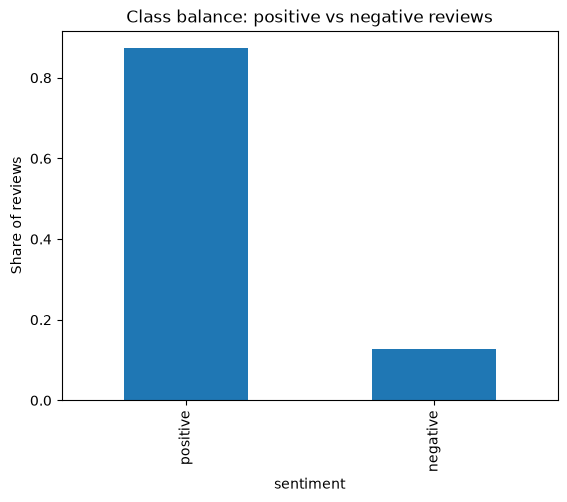

In [4]:
df["sentiment"] = (df["rating"] >= 4).astype(int)

balance = df["sentiment"].value_counts(normalize=True).rename({0: "negative", 1: "positive"})
print(balance)

balance.plot(kind="bar", title="Class balance: positive vs negative reviews")
plt.ylabel("Share of reviews")
plt.savefig("Report/images/class_balance.png", dpi=150, bbox_inches="tight")  # TODO: create Report/images/ first
plt.show()


**TODO — discuss the balance you find here.** Note: in last year's Movies & TV
version of this assignment the split was roughly 82k positive vs 19.6k negative (~81/19).
Check whether CDs & Vinyl shows a similarly skewed distribution — if so, say explicitly
in the report that this affects your choice of evaluation metric later (prefer F1 /
balanced accuracy over raw accuracy) and possibly your modeling choice (class_weight="balanced").


## 2. Preprocessing & Analysis

### Should all reviews be included?
This is an explicit question in the 2026 brief (not present in the 2025 version) — answer it
with evidence, don't just assert it. Check for: empty text, text that is only punctuation/emoji,
extremely short reviews (e.g. 1-2 tokens), and near-duplicate spam reviews.


In [5]:
empty_mask = df["text"].isna() | (df["text"].str.strip() == "")
punct_only_mask = df["text"].fillna("").str.fullmatch(r"[\W_]*")
short_mask = df["text"].fillna("").str.split().str.len() <= 2

print("Empty reviews:", empty_mask.sum())
print("Punctuation/emoji-only reviews:", punct_only_mask.sum())
print("Reviews with <=2 words:", short_mask.sum())

# TODO: decide and justify your inclusion rule, e.g.:
# df_clean = df.loc[~empty_mask & ~punct_only_mask].copy()


Empty reviews: 18
Punctuation/emoji-only reviews: 64
Reviews with <=2 words: 4565


In [6]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)      # strip the HTML line breaks visible in this dataset
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # strip URLs
    text = re.sub(r"[^a-z\s]", " ", text)        # strip punctuation/digits
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].fillna("").apply(clean_text)
df["tokens"] = df["clean_text"].str.split()
df.head()


,Unnamed: 0,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,sentiment,clean_text,tokens
0,0,5.0,Love music,This was a gift for someone,B00N1F0BKK,B00N1F0BKK,AGSRCBGM3T7IQE3CQRFF6346JHSA,1539921682876,0,True,1,this was a gift for someone,"[this, was, a, gift, for, someone]"
1,1,2.0,Recording quailiy is dissapointing,I am in love with the album of Uria Heep.<br /...,B07MNV5ZXN,B07MNV5ZXN,AEPA6ATLYCE57DCCN3GQTQAAZU6A,1668565115999,0,True,0,i am in love with the album of uria heep one o...,"[i, am, in, love, with, the, album, of, uria, ..."
2,2,5.0,Unique,Not every artist in the music Biz just wants t...,B000TP5TEI,B000TP5TEI,AFG4ELVNGCXLB36QB5WNPNFZE2QA,1303014201000,1,True,1,not every artist in the music biz just wants t...,"[not, every, artist, in, the, music, biz, just..."
3,3,5.0,Five Stars,"excellent product, thank you very much.",B000ELJACO,B000ELJACO,AF6DEMZC4G5OJD2SZLOOF6VFTTYA,1412044018000,0,True,1,excellent product thank you very much,"[excellent, product, thank, you, very, much]"
4,4,4.0,Italian Angel,"This Italian Beauty has a wonderful,Angelic & ...",B000UZ4C36,B000UZ4C36,AGXR7APN2FJYIWTJT3E2LUB2GFCQ,1286731853000,0,True,1,this italian beauty has a wonderful angelic op...,"[this, italian, beauty, has, a, wonderful, ang..."


**TODO — justify every choice above** (lowercasing, HTML-tag stripping, URL removal,
punctuation/digit removal, no stemming/lemmatization yet). Reference why you did or didn't
lemmatize/stem at this stage — the mutual information and BoW work in Task 3 depend on it.


In [7]:
n_reviews = len(df)
avg_words = df["tokens"].str.len().mean()
vocab = set(w for toks in df["tokens"] for w in toks)

print(f"Number of reviews: {n_reviews}")
print(f"Average words per review: {avg_words:.2f}")
print(f"Number of unique words: {len(vocab)}")

# TODO: add more descriptive stats if useful — review length distribution, rating distribution, etc.


Number of reviews: 50000
Average words per review: 77.73
Number of unique words: 69650


In [8]:
from collections import Counter

all_words = [w for toks in df["tokens"] for w in toks]
top50 = Counter(all_words).most_common(50)
top50_df = pd.DataFrame(top50, columns=["word", "count"])
top50_df.to_csv("Report/tables/top50_words_before_stopwords.csv", index=False)  # TODO: create Report/tables/ first
top50_df


,word,count
0,the,196329
1,and,109170
2,of,95485
3,a,93117
4,i,83043
5,to,81189
6,is,72401
7,this,67008
8,it,64490
9,in,48344


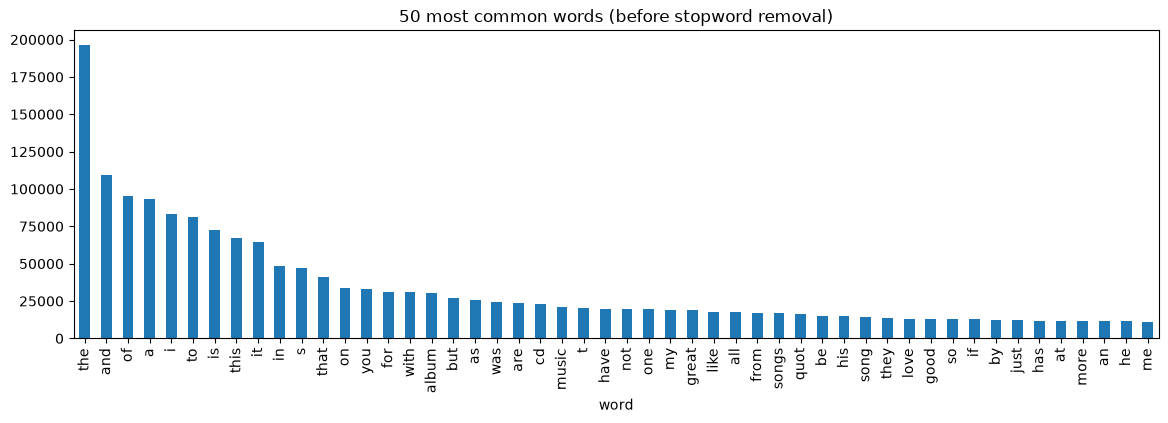

In [9]:
top50_df.set_index("word")["count"].plot(kind="bar", figsize=(14, 4),
                                          title="50 most common words (before stopword removal)")
plt.savefig("Report/images/top50_words.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Bag-of-Words Model
Remove stopwords using scikit-learn's built-in list, then look at the top 100 words and
their mutual information with the sentiment label.


In [10]:
df["tokens_nostop"] = df["tokens"].apply(lambda toks: [w for w in toks if w not in ENGLISH_STOP_WORDS])

all_words_nostop = [w for toks in df["tokens_nostop"] for w in toks]
top100 = Counter(all_words_nostop).most_common(100)
top100_words = [w for w, _ in top100]
top100_df = pd.DataFrame(top100, columns=["word", "count"])
top100_df.to_csv("Report/tables/top100_words_after_stopwords.csv", index=False)
top100_df.head(20)


,word,count
0,s,47296
1,album,30072
2,cd,23208
3,music,21119
4,t,20043
5,great,18689
6,like,17834
7,songs,16805
8,quot,16049
9,song,14345


In [11]:
# Build a binary/count feature matrix restricted to the top-100 vocabulary,
# so mutual information can be computed against the sentiment label.
top100_vectorizer = TfidfVectorizer(vocabulary=top100_words, use_idf=False, binary=True)
X_top100 = top100_vectorizer.fit_transform(df["clean_text"])

mi = mutual_info_classif(X_top100, df["sentiment"], discrete_features=True, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"word": top100_words, "mutual_information": mi}).sort_values(
    "mutual_information", ascending=False)
mi_df.to_csv("Report/tables/top100_mutual_information.csv", index=False)
mi_df.head(20)


c:\Projects\Advanced Machine Learning\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Projects\Advanced Machine Learning\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Projects\Advanced Machine Learning\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Projects\Advanced Machine Learning\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label,

,word,mutual_information
5,great,0.009654
86,bad,0.006394
10,love,0.005747
6,like,0.005256
19,don,0.004416
26,better,0.004377
12,just,0.004282
11,good,0.004037
7,songs,0.003274
38,sounds,0.002746


**TODO — interpret the top mutual-information words.** Which of them are
generic sentiment words (e.g. "great", "love", "worst") versus domain-specific to CDs &
Vinyl (e.g. "vinyl", "pressing", "scratched", "remaster")? That distinction is worth a
sentence in the report — it tells you something about how transferable this model would be
to a different product category.


## 4. Feature Representation

### TF-IDF (top-100 vocabulary) + Logistic Regression


In [12]:
tfidf_vectorizer = TfidfVectorizer(vocabulary=top100_words)
X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

X_tr, X_te, y_tr, y_te = train_test_split(X_tfidf, y, test_size=0.2,
                                           random_state=RANDOM_STATE, stratify=y)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_tfidf.fit(X_tr, y_tr)
print(classification_report(y_te, lr_tfidf.predict(X_te)))


              precision    recall  f1-score   support

           0       0.56      0.05      0.09      1271
           1       0.88      0.99      0.93      8729

    accuracy                           0.87     10000
   macro avg       0.72      0.52      0.51     10000
weighted avg       0.84      0.87      0.83     10000



### Word2Vec — own model vs. pretrained
Train your own Word2Vec on the CDs & Vinyl corpus and compare it against a pretrained model
(e.g. `word2vec-google-news-300` via `gensim.downloader`). Discuss coverage of your
domain-specific vocabulary (e.g. "vinyl", "turntable", "pressing") — this is usually where
the pretrained model underperforms and your own model has an edge.


In [14]:
import gensim
from gensim.models import Word2Vec
import gensim.downloader as gensim_api

# Own model, trained on this corpus
w2v_own = Word2Vec(sentences=df["tokens_nostop"].tolist(), vector_size=100, window=5,
                    min_count=5, workers=4, seed=RANDOM_STATE)

# Pretrained model — downloads on first use (needs network access)
# w2v_pretrained = gensim_api.load("word2vec-google-news-300")

# TODO: compare vocabulary coverage of both models against your corpus vocabulary,
# and compare a handful of nearest-neighbour queries (e.g. w2v_own.wv.most_similar("vinyl")).


**TODO — state which Word2Vec model you choose for the rest of the assignment, and why.**

### Word embeddings → document embeddings


In [15]:
def document_embedding(tokens, model, vector_size):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

VECTOR_SIZE = w2v_own.vector_size
df["doc_embedding"] = df["tokens_nostop"].apply(lambda toks: document_embedding(toks, w2v_own, VECTOR_SIZE))
X_doc_embeddings = np.vstack(df["doc_embedding"].values)
X_doc_embeddings.shape


(50000, 100)

**TODO — explain the averaging choice above** (mean pooling over word vectors) and
mention alternatives you considered (TF-IDF-weighted average, max-pooling, etc.) even if you
didn't implement them.


## 5. Feature Selection & Dimensionality Reduction
Project the Word2Vec **word** embeddings (not document embeddings) to 2D with PCA and ICA.


In [16]:
words = list(w2v_own.wv.index_to_key)
word_vectors = np.array([w2v_own.wv[w] for w in words])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
word_vectors_pca = pca.fit_transform(word_vectors)

ica = FastICA(n_components=2, random_state=RANDOM_STATE)
word_vectors_ica = ica.fit_transform(word_vectors)

# TODO: plot a readable subset (e.g. 200-300 most frequent words, or a hand-picked
# set of sentiment + domain words) with labels, for both PCA and ICA, and compare.


**TODO — discuss whether semantically similar words end up close together** in each
projection, with at least one concrete example pair (e.g. "great"/"excellent" vs.
"scratched"/"damaged"). Note which of PCA or ICA gives a more interpretable picture and why.


## 6. Modeling & Evaluation
Train KNN, Naive Bayes and Logistic Regression on the Word2Vec **document** representations.

Multinomial Naive Bayes requires non-negative features and cannot be used directly on
embeddings (which contain negative values). We use `GaussianNB` instead — TODO: justify
this choice explicitly in the report (assumes features are roughly normally distributed per
class, which is a reasonable approximation for averaged embeddings, unlike raw counts).


In [17]:
X_tr, X_te, y_tr, y_te = train_test_split(X_doc_embeddings, y, test_size=0.2,
                                           random_state=RANDOM_STATE, stratify=y)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, model in models.items():
    scores = []
    for train_idx, val_idx in cv.split(X_tr):
        model.fit(X_tr[train_idx], y_tr.iloc[train_idx])
        preds = model.predict(X_tr[val_idx])
        scores.append(f1_score(y_tr.iloc[val_idx], preds))
    cv_results[name] = scores
    print(f"{name}: mean CV F1 = {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


KNN: mean CV F1 = 0.9337 (+/- 0.0009)
GaussianNB: mean CV F1 = 0.6320 (+/- 0.0031)
LogisticRegression: mean CV F1 = 0.9338 (+/- 0.0011)


### Hyperparameter search on Logistic Regression

**Important — read this before reporting a number.** The score `GridSearchCV` reports
internally (`.best_score_`) is itself a cross-validated estimate used to *pick* the
hyperparameters. It is not the number you report as your final model's performance —
report that on the held-out test set instead, evaluated once, after the search is done.


In [18]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                     param_grid=param_grid, scoring="f1", cv=5, n_jobs=-1)
grid.fit(X_tr, y_tr)

print("Best params:", grid.best_params_)
print("Best CV F1 (search score, NOT your final reported score):", grid.best_score_)

best_lr = grid.best_estimator_
test_preds = best_lr.predict(X_te)
print("\nHeld-out test set performance (THIS is what you report as final):")
print(classification_report(y_te, test_preds))


Best params: {'C': 1, 'class_weight': None}
Best CV F1 (search score, NOT your final reported score): 0.933841109474065

Held-out test set performance (THIS is what you report as final):
              precision    recall  f1-score   support

           0       0.55      0.14      0.22      1271
           1       0.89      0.98      0.93      8729

    accuracy                           0.88     10000
   macro avg       0.72      0.56      0.58     10000
weighted avg       0.84      0.88      0.84     10000



### Save the best-performing model
The deliverable requires a single pickled `Pipeline` containing the fitted vectorizer/scaler
*and* the fitted model, so it can predict directly from raw text. TODO: decide whether your
best model is the TF-IDF+LR from Task 4 or the Word2Vec+LR from this task, and build the
matching Pipeline — a raw `LogisticRegression` object alone is not sufficient.


In [ ]:
# Example for the TF-IDF route (adjust if Word2Vec ends up being your best model —
# in that case wrap document_embedding() in a custom sklearn-compatible transformer instead).
best_pipeline = Pipeline([
    ("tfidf", tfidf_vectorizer),
    ("clf", lr_tfidf),
])

with open("Team-X20pickle", "wb") as f:
    pickle.dump(best_pipeline, f)

# Sanity check: load it back and predict on raw text
with open("Team-20.pickle", "rb") as f:
    loaded_pipeline = pickle.load(f)
print(loaded_pipeline.predict(["This album is absolutely amazing, best purchase ever"]))


[1]


**TODO — compare your Word2Vec classifiers (KNN vs GaussianNB vs LR)** side by side
in a small results table, and state which one you'd recommend and why (accuracy alone is not
enough given the class imbalance found in Task 1 — report F1 / balanced accuracy too).


## 7. Clustering & Topic Modeling

### Agglomerative Clustering & DBSCAN on Word2Vec word embeddings


In [20]:
# Use a manageable sample of word vectors (or all of them if small enough)
sample_size = min(2000, len(word_vectors))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(word_vectors), size=sample_size, replace=False)
word_vectors_sample = word_vectors[sample_idx]
words_sample = [words[i] for i in sample_idx]

agg = AgglomerativeClustering(n_clusters=10)
agg_labels = agg.fit_predict(word_vectors_sample)

dbscan = DBSCAN(eps=0.5, min_samples=5)  # TODO: tune eps via a k-distance plot, don't guess
dbscan_labels = dbscan.fit_predict(word_vectors_sample)

print("Agglomerative cluster sizes:", np.bincount(agg_labels))
print("DBSCAN cluster count (excl. noise):", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("DBSCAN noise points:", (dbscan_labels == -1).sum())


Agglomerative cluster sizes: [ 624   46   20   13    2 1201    8   41   44    1]
DBSCAN cluster count (excl. noise): 1
DBSCAN noise points: 803


**TODO — inspect a handful of clusters** (print the words in 3-4 clusters from each
method) and discuss whether they correspond to something meaningful (sentiment, genre,
format-related terms like "vinyl"/"CD"/"turntable", etc).

### Topic Modeling — BERTopic and FuzzyTM

Two practical notes from the assignment brief:
- BERTopic downloads a sentence-transformer model on first use, and accepts precomputed
  embeddings — you can hand it your own Word2Vec/TF-IDF document embeddings instead of
  letting it fetch its default model, which avoids the download entirely if network access
  is a problem.
- FuzzyTM builds dense vocabulary x document matrices and will exhaust an ordinary laptop's
  memory on the full review vocabulary. Prune rare words before fitting it, and **report the
  threshold you used** — this is explicitly asked for.


In [22]:
from bertopic import BERTopic

# Passing precomputed embeddings avoids BERTopic downloading its own sentence-transformer.
docs = df["clean_text"].tolist()
topic_model = BERTopic(embedding_model=None)  # TODO: confirm this signature against your BERTopic version
topics, probs = topic_model.fit_transform(docs, embeddings=X_doc_embeddings)

topic_model.get_topic_info().head(10)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,29919,-1_to_this_it_and,"[to, this, it, and, the, you, album, is, of, t...",[i hate that i waited so long to listen to viv...
1,0,1355,0_quot_amp_the_you,"[quot, amp, the, you, and, of, song, on, is, are]",[for d fans who were introduced to the group a...
2,1,1271,1_recording_symphony_orchestra_performance,"[recording, symphony, orchestra, performance, ...",[carlos chavez has had both the honor and the ...
3,2,808,2_dvd_concert_live_video,"[dvd, concert, live, video, saw, tour, seen, f...","[and a dvd, great cd dvd, great dvd fun concert]"
4,3,724,3_metal_rock_bands_roll,"[metal, rock, bands, roll, band, punk, heavy, ...","[death to all but metal i love this band, this..."
5,4,504,4_don_didn_doesn_know,"[don, didn, doesn, know, care, can, won, like,...",[there are only a couple of good songs on here...
6,5,500,5_fan_big_huge_must,"[fan, big, huge, must, am, fans, gift, collect...","[i am a huge fan, if you re a fan get it but n..."
7,6,251,6_case_cracked_amazon_received,"[case, cracked, amazon, received, item, damage...",[received this cd today and the case is cracke...
8,7,242,7_none_tvm_grt_yip,"[none, tvm, grt, yip, done, aaaaa, boggy, asdm...","[none, none, none]"
9,8,179,8_new_brand_old_love,"[new, brand, old, love, artist, orleans, favor...","[great new music, great new cd, great new album]"


In [23]:
# FuzzyTM — prune the vocabulary first to avoid exhausting memory.
MIN_DOC_FREQ = 20  # TODO: justify this threshold, tune if needed, and report the final value used
word_freq = Counter(w for toks in df["tokens_nostop"] for w in set(toks))
pruned_vocab = {w for w, c in word_freq.items() if c >= MIN_DOC_FREQ}
print(f"Vocabulary pruned from {len(word_freq)} to {len(pruned_vocab)} words (min_doc_freq={MIN_DOC_FREQ})")

# TODO: fit FuzzyTM on the pruned corpus. Consider running this step on a subsample of
# reviews too if memory is still an issue even after pruning.


Vocabulary pruned from 69338 to 7556 words (min_doc_freq=20)


**TODO — evaluate topic quality with an appropriate metric** (e.g. topic coherence,
topic diversity) for both BERTopic and FuzzyTM, and compare them.


## 8. Evaluation & Discussion

**TODO** — pull together, in prose, referencing the tables/figures produced above:
- Which representation (TF-IDF vs Word2Vec-own vs Word2Vec-pretrained) and which classifier
  performed best, with numbers.
- Why you think that happened (dataset size, vocabulary characteristics, class imbalance).
- Limitations of your approach (e.g. mean-pooling loses word order, small training set for
  your own Word2Vec, DBSCAN's sensitivity to `eps`, FuzzyTM's memory constraints).
- Concrete ideas for improvement (e.g. transformer-based embeddings, weighted document
  embeddings, more thorough hyperparameter search, addressing class imbalance directly).
